## Analysis of an E-commerce Dataset Part 2

The goal of the second analysis task is to train linear regression models to predict users' ratings towards items. This involves a standard Data Science workflow: exploring data, building models, making predictions, and evaluating results. In this task, we will explore the impacts of feature selections and different sizes of training/testing data on the model performance. We will use another cleaned combined e-commerce sub-dataset that **is different from** the one in “Analysis of an E-commerce Dataset” task 1.

### Import Cleaned E-commerce Dataset
The csv file named 'cleaned_ecommerce_dataset.csv' is provided. You may need to use the Pandas method, i.e., `read_csv`, for reading it. After that, please print out its total length.

In [30]:
student_name = "Jaya sri Garipally"
student_id = "47822872"

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import r2_score

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

In [32]:
data_df = pd.read_csv("cleaned_ecommerce_dataset.csv")

### Explore the Dataset

* Use the methods, i.e., `head()` and `info()`, to have a rough picture about the data, e.g., how many columns, and the data types of each column.
* As our goal is to predict ratings given other columns, please get the correlations between helpfulness/gender/category/review and rating by using the `corr()` method.

  Hints: To get the correlations between different features, you may need to first convert the categorical features (i.e., gender, category and review) into numerial values. For doing this, you may need to import `OrdinalEncoder` from `sklearn.preprocessing` (refer to the useful exmaples [here](https://pbpython.com/categorical-encoding.html))
* Please provide ___necessary explanations/analysis___ on the correlations, and figure out which are the ___most___ and ___least___ corrleated features regarding rating. Try to ___discuss___ how the correlation will affect the final prediction results, if we use these features to train a regression model for rating prediction. In what follows, we will conduct experiments to verify your hypothesis.

In [33]:
data_df.info() # Display summary information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2685 entries, 0 to 2684
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   userId       2685 non-null   int64  
 1   timestamp    2685 non-null   int64  
 2   review       2685 non-null   object 
 3   item         2685 non-null   object 
 4   rating       2685 non-null   float64
 5   helpfulness  2685 non-null   float64
 6   gender       2685 non-null   object 
 7   category     2685 non-null   object 
 8   item_id      2685 non-null   int64  
 9   item_price   2685 non-null   float64
 10  user_city    2685 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 230.9+ KB


In [34]:
data_df.head() # Display the first few rows of the DataFrame 

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4


In [35]:
data_df.shape # Display the dimensions of the DataFrame (rows, columns)

(2685, 11)

In [36]:
from sklearn.preprocessing import OrdinalEncoder # Import the OrdinalEncoder class from the sklearn.preprocessing module

ord_enc = OrdinalEncoder()  # Create an instance of the OrdinalEncoder class

data_df["gender_code"] = ord_enc.fit_transform(data_df[["gender"]]) # Encode the 'gender' column into ordinal integers and store the result in 'gender_code'

In [37]:
data_df["review_code"] = ord_enc.fit_transform(data_df[["review"]]) # Encode the 'review' column into ordinal integers and store the result in 'review_code'

In [38]:
data_df["category_code"] = ord_enc.fit_transform(data_df[["category"]]) # Encode the 'category' column into ordinal integers and store the result in 'category_code'

In [39]:
data_df.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city,gender_code,review_code,category_code
0,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4,1.0,1618.0,8.0
1,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4,1.0,1125.0,8.0
2,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4,1.0,2185.0,8.0
3,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4,1.0,2243.0,5.0
4,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4,1.0,1033.0,5.0


In [40]:
# Compute the correlation between features and rating
help_vs_rating = data_df["helpfulness"].corr(data_df["rating"])
gender_vs_rating = data_df["gender_code"].corr(data_df["rating"])
category_vs_rating = data_df["category_code"].corr(data_df["rating"])
review_vs_rating = data_df["review_code"].corr(data_df["rating"])

# Print the correlation values
print(help_vs_rating)
print(review_vs_rating) 
print(gender_vs_rating)
print(category_vs_rating)

-0.007523337726844577
-0.036118386552122385
-0.03433661424208267
-0.16315765340915647


### Split Training and Testing Data
* Machine learning models are trained to help make predictions for the future. Normally, we need to randomly split the dataset into training and testing sets, where we use the training set to train the model, and then leverage the well-trained model to make predictions on the testing set.
* To further investigate whether the size of the training/testing data affects the model performance, please random split the data into training and testing sets with different sizes:
    * Case 1: training data containing 10% of the entire data;
    * Case 2: training data containing 90% of the entire data.
* Print the shape of training and testing sets in the two cases.

In [41]:
# Split the dataset into training and testing sets for case 1 and case 2
train_case_1, test_case_1 = train_test_split(data_df, test_size=0.10, random_state=40)
train_case_2, test_case_2 = train_test_split(data_df, test_size=0.90, random_state=40)

# Print the shapes of the training and testing sets for case 1
print(train_case_1.shape)
print(test_case_1.shape)

# Print the shapes of the training and testing sets for case 2
print(train_case_2.shape)
print(train_case_2.shape)

(2416, 14)
(269, 14)
(268, 14)
(268, 14)


### Train Linear Regression Models with Feature Selection under Cases 1 & 2
* When training a machine learning model for prediction, we may need to select the most important/correlated input features for more accurate results.
* To investigate whether feature selection affects the model performance, please select two most correlated features and two least correlated features from helpfulness/gender/category/review regarding rating, respectively.
* Train four linear regression models by following the conditions:
    - (model-a) using the training/testing data in case 1 with two most correlated input features
    - (model-b) using the training/testing data in case 1 with two least correlated input features
    - (model-c) using the training/testing data in case 2 with two most correlated input features
    - (model-d) using the training/testing data in case 2 with two least correlated input features
* By doing this, we can verify the impacts of the size of traing/testing data on the model performance via comparing model-a and model-c (or model-b and model-d); meanwhile the impacts of feature selection can be validated via comparing model-a and model-b (or model-c and model-d).    

In [42]:
# Create a linear regression model for case 1
model_a = linear_model.LinearRegression()
# Prepare the training data for case 1
X_train_a = train_case_1[['category_code','review_code']]
y_train_a = train_case_1['rating']

X_test_a = test_case_1[['category_code','review_code']]
y_test_a = test_case_1['rating']

# Fit the model to the training data for case 1
model_a.fit(X_train_a, y_train_a)


LinearRegression()

In [43]:
#Case 1
model_b = linear_model.LinearRegression()
X_train_b = train_case_1[['helpfulness','gender_code']]
y_train_b = train_case_1['rating']

X_test_b = test_case_1[['helpfulness','gender_code']]
y_test_b = test_case_1['rating']

model_b.fit(X_train_b, y_train_b)

LinearRegression()

In [44]:
# Create a linear regression model for case 2
model_c = linear_model.LinearRegression()
# Prepare the training data for case 2
X_train_c = train_case_2[['category_code','review_code']]
y_train_c = train_case_2['rating']

X_test_c = test_case_2[['category_code','review_code']]
y_test_c = test_case_2['rating']

# Fit the model to the training data for case 2
model_c.fit(X_train_c, y_train_c)

LinearRegression()

In [45]:
#Case 2
model_d = linear_model.LinearRegression()
X_train_d = train_case_2[['helpfulness','gender_code']]
y_train_d = train_case_2['rating']

X_test_d = test_case_2[['helpfulness','gender_code']]
y_test_d = test_case_2['rating']

model_d.fit(X_train_d, y_train_d)

LinearRegression()

### Evaluate Models
* Evaluate the performance of the four models with two metrics, including MSE and Root MSE
* Print the results of the four models regarding the two metrics

In [46]:
predicted_a = model_a.predict(X_test_a)
mse_a =((np.array(y_test_a)-predicted_a)**2).sum()/len(y_test_a) # Calculate Mean Squared Error (MSE) for case 1
rmse_a = np.sqrt(mse_a) # Calculate Root Mean Squared Error (RMSE) for case 1
# Print the MSE and RMSE for case 1
print("MSE:", mse_a)
print("Root MSE:", rmse_a)

MSE: 1.911931944260951
Root MSE: 1.3827262723550713


In [47]:
# Case 1
predicted=model_b.predict(X_test_b)
mse_b=((np.array(y_test_b)-predicted)**2).sum()/len(y_test_b)
rmse_b=np.sqrt(mse_b)
print("MSE:",mse_b)
print("Root MSE:",rmse_b)


MSE: 1.9344327102388086
Root MSE: 1.3908388512832135


In [48]:
predicted=model_c.predict(X_test_c)
mse_c=((np.array(y_test_c)-predicted)**2).sum()/len(y_test_c) # Calculate Mean Squared Error (MSE) for case 2
rmse_c=np.sqrt(mse_c) # Calculate Root Mean Squared Error (RMSE) for case 2
# Print the MSE and RMSE for case 2
print("MSE:",mse_c)
print("Root MSE:",rmse_c)

MSE: 1.7925082508785923
Root MSE: 1.3388458652431177


In [49]:
# Case 2
predicted=model_d.predict(X_test_d)
mse_d=((np.array(y_test_d)-predicted)**2).sum()/len(y_test_d)
rmse_d=np.sqrt(mse_d)
print("MSE:",mse_d)
print("Root MSE:",rmse_d)

MSE: 1.816622231978342
Root MSE: 1.347821290816532


### Visualize, Compare and Analyze the Results
* Visulize the results, and perform ___insightful analysis___ on the obtained results. For better visualization, you may need to carefully set the scale for the y-axis.
* Normally, the model trained with most correlated features and more training data will get better results. Do you obtain the similar observations? If not, please ___explain the possible reasons___.

In [50]:
mse_a = 1.911931944260951
mse_b = 1.9344327102388086
mse_c = 1.7925082508785923
mse_d = 1.816622231978342

rmse_a = 1.3827262723550713
rmse_b = 1.3908388512832135
rmse_c = 1.3388458652431177
rmse_d = 1.347821290816532


In [51]:
mse_df = pd.DataFrame({'mse':[mse_a, mse_b, mse_c, mse_d]}, index=['model_a','model_b','model_c','model_d'])
rmse_df = pd.DataFrame({'rmse':[rmse_a, rmse_b, rmse_c, rmse_d]}, index=['model_a','model_b','model_c','model_d'])

In [52]:
mse_df.head()

,mse
model_a,1.911932
model_b,1.934433
model_c,1.792508
model_d,1.816622


In [53]:
rmse_df.head()

,rmse
model_a,1.382726
model_b,1.390839
model_c,1.338846
model_d,1.347821


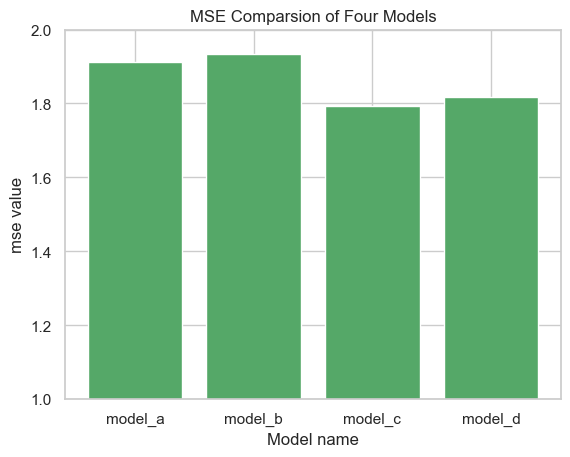

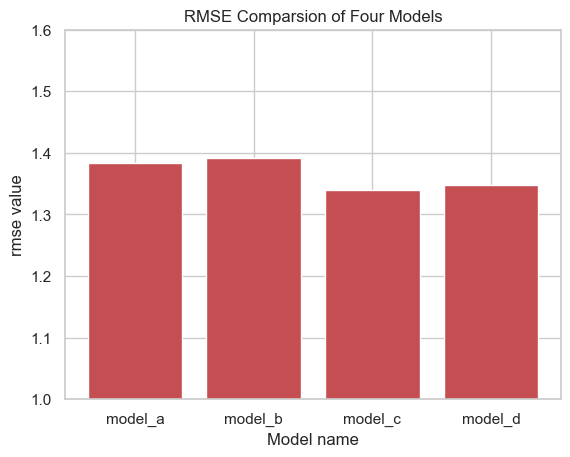

In [54]:
sns.set(style = 'whitegrid')
plt.ylim(1, 2)
plt.title('MSE Comparsion of Four Models')
plt.xlabel('Model name')
plt.ylabel('mse value')
plt.bar(data = mse_df, height = 'mse', x=['model_a','model_b','model_c','model_d'], color = 'g')
plt.show()

plt.ylim(1, 1.6)
plt.title('RMSE Comparsion of Four Models')
plt.xlabel('Model name')
plt.ylabel('rmse value')
plt.bar(data = rmse_df, height = 'rmse', x=['model_a','model_b','model_c','model_d'], color = 'r')
plt.show()

## Observation
- Bar-chart diagram is use to perform comparsion of metric values across different models
- From bar-chart we can see which groups are highest or most common and how other groups compare against the other which is easy to understand and interpret the data

## Analysis
- Mse Comparsion: The bar plot depicting MSE values clearly illustrates that Model C has the lowest MSE value among all models,indicating better prediction accuracy. Model B has the highest MSE, suggesting poorer performance
- The one with the lowest MSE is often preferred as it demonstrates better fitting to the data.
- RMSE Comparsion: Model C also has the lowest RMSE, incdicating more accurate predictions, while Model B has the highest RMSE
- Efficacy of Feature Selection: Model C might have undergone a more effective feature selection process, ensuring that only the most relevant features are utilized for prediction.
- Data Representativeness: The training data used for Model C may be more representative of the true underlying distribution, enabling the model to learn more effectively from the available data.
- Model Complexity: Model C could have a simpler and more interpretable architecture compared to Model B, which may lead to better generalization and lower error rates.
- Hyperparameter Tuning: Model C might have been subjected to more rigorous hyperparameter tuning, optimizing its performance for the given task and dataset.

### Data Science Ethics
*Please read the following examples [Click here to read the example_1.](https://www.vox.com/covid-19-coronavirus-us-response-trump/2020/5/18/21262265/georgia-covid-19-cases-declining-reopening) [Click here to read the example_2.](https://viborc.com/ethics-and-ethical-data-visualization-a-complete-guide/)

*Then view the picture ![My Image](figure_portfolio2.png "This is my image")
Please compose an analysis of 100-200 words that evaluates potential ethical concerns associated with the infographic, detailing the reasons behind these issues.


## Analysis
Two tables with the 2008 Summer Olympic medal counts are presented in the infographics; one table is arranged according to total medals, while the other is arranged according to gold medals. The way the information is presented could raise ethical issues since it could lead to a skewed perception of what constitutes Olympic achievement. As viewers may judge one sorting technique as more representative of success than another, the various methods of sorting may have an impact on the perceived achievements of each nation. Furthermore, it may be implied that gold medals are more valuable than more medals overall by the design decision to rank golf medals in a visible table. Unintentionally represented by silver and bronze medals, this could distort public perception.